Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d
from pyhgf.model import Network
from itertools import cycle

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
np.random.seed(123)

n_trials = 15
x = np.arange(0, n_trials)

mu_hr, sigma_hr = 75.0, 3.0
mu_bel, sigma_bel = 45.0, 5.0
alpha, beta = -10.0, 5.0
heart_rates = np.random.normal(mu_hr, sigma_hr, n_trials) + np.sin(x * 0.1)

f = interp1d(x, heart_rates, kind="cubic")
new_heart_rate = f(np.arange(0, n_trials - 1, 0.001))

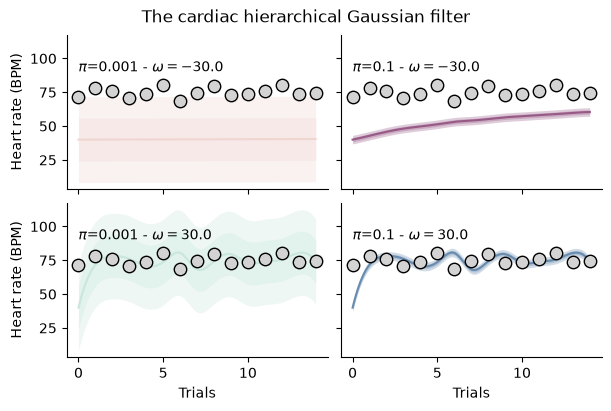

In [3]:
fig, axs = plt.subplots(figsize=(6, 4), ncols=2, nrows=2, sharex=True, sharey=True)

colors = cycle(["#efd6d1", "#975986", "#c9e7dc", "#688bae"])
for row_idx, tonic_volatility in enumerate([-30.0, 30.0]):
    for cols_idx, precision in enumerate([0.001, 0.10]):
        c = next(colors)

        axs[row_idx, cols_idx].scatter(
            x, heart_rates, s=80, color="lightgrey", edgecolor="k", zorder=10
        )

        network = (
            Network(volatility_updates="unbounded")
            .add_nodes(precision=precision, expected_precision=precision)
            .add_nodes(value_children=0, mean=40.0, tonic_volatility=tonic_volatility)
        )
        network.input_data(input_data=heart_rates)
        std = np.sqrt(1 / network.node_trajectories[0]["expected_precision"])

        mu = network.node_trajectories[0]["expected_mean"]
        f = interp1d(x, mu, kind="cubic")
        new_mu = f(np.arange(0, n_trials - 1, 0.001))

        f = interp1d(x, std, kind="cubic")
        new_std = f(np.arange(0, n_trials - 1, 0.001))

        axs[row_idx, cols_idx].fill_between(
            x=np.arange(0, n_trials - 1, 0.001),
            y1=new_mu - new_std,
            y2=new_mu + new_std,
            color=c,
            alpha=0.3,
            linewidth=0,
        )
        axs[row_idx, cols_idx].fill_between(
            x=np.arange(0, n_trials - 1, 0.001),
            y1=new_mu - 0.5 * new_std,
            y2=new_mu + 0.5 * new_std,
            color=c,
            alpha=0.3,
            linewidth=0,
        )
        axs[row_idx, cols_idx].plot(
            np.arange(0, n_trials - 1, 0.001),
            new_mu,
            color=c,
        )
        axs[row_idx, cols_idx].text(
            0, 90, rf"$\pi$={precision} - $\omega = {tonic_volatility}$", fontsize=10
        )

axs[0, 0].set(ylabel="Heart rate (BPM)")
axs[1, 0].set(xlabel="Trials", ylabel="Heart rate (BPM)")
axs[1, 1].set(xlabel="Trials")
fig.suptitle("The cardiac hierarchical Gaussian filter")
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_4_illustration.svg")